Connected to Python 3.11.9

In [ ]:
# import libraries
from pprint import PrettyPrinter

import pandas as pd
from IPython.display import VimeoVideo
from pymongo import MongoClient

In [ ]:
pp = PrettyPrinter(indent=2)
# connect to MongoDB
client = MongoClient("mongodb://127.0.0.1:27017")
client.list_databases()

In [ ]:
pp.pprint(list(client.list_databases()))

[ {'empty': False, 'name': 'admin', 'sizeOnDisk': 40960},
  {'empty': False, 'name': 'air-quality', 'sizeOnDisk': 29052928},
  {'empty': False, 'name': 'config', 'sizeOnDisk': 110592},
  {'empty': False, 'name': 'local', 'sizeOnDisk': 73728}]


In [ ]:
db = client["air-quality"]

In [ ]:
pp.pprint(list(db.list_collection_names()))

['lagos', 'dar-es-salaam', 'nairobi']


In [ ]:
for c in db.list_collections():
    print(c["name"])

lagos
dar-es-salaam
nairobi


In [ ]:
nairobi = db["nairobi"]

In [ ]:
nairobi.count_documents({})

202212

In [ ]:
resutlt = nairobi.find_one({})

In [ ]:
pp.pprint(resutlt)

{ '_id': ObjectId('6525d772f44bfedd842a6fcc'),
  'metadata': { 'lat': -1.3,
                'lon': 36.785,
                'measurement': 'temperature',
                'sensor_id': 58,
                'sensor_type': 'DHT22',
                'site': 29},
  'temperature': 16.5,
  'timestamp': '2018-09-01 00:00:04.301'}


In [ ]:
nairobi.distinct("metadata.site")

[6, 29]

In [ ]:
nairobi.count_documents({"metadata.site": 6})

70360

In [ ]:
print("Documents from site 6:", nairobi.count_documents({"metadata.site": 6}))
print("Documents from site 29:", nairobi.count_documents({"metadata.site": 29}))

Documents from site 6: 70360
Documents from site 29: 131852


In [ ]:
# Aggregation Framework
# count number of documents per site
result = nairobi.aggregate([
    {
        "$group": {
            "_id": "$metadata.site",
            "count": {"$sum": 1}
        }
    }
])

In [ ]:
pp.pprint(list(result))

[{'_id': 6, 'count': 70360}, {'_id': 29, 'count': 131852}]


In [ ]:
# or
result =  nairobi.aggregate([
    {
        "$group": {
            "_id": "$metadata.site",
            "count": {"$count": {}}}}
])
pp.pprint(list(result))

[{'_id': 29, 'count': 131852}, {'_id': 6, 'count': 70360}]


In [ ]:
nairobi.distinct("metadata.measurement")

['P1', 'P2', 'humidity', 'temperature']

In [ ]:
from pymongo import UpdateOne

batch_size = 1000
bulk_ops = []

cursor = nairobi.find({}, {"metadata": 1})

for i, doc in enumerate(cursor, 1):
    try:
        metadata_fixed = ast.literal_eval(doc["metadata"])
        bulk_ops.append(
            UpdateOne(
                {"_id": doc["_id"]},
                {"$set": {"metadata": metadata_fixed}}
            )
        )
    except:
        continue

    # Execute every batch
    if i % batch_size == 0:
        nairobi.bulk_write(bulk_ops)
        bulk_ops = []
        print(f"{i} documents processed...")

# Run remaining operations
if bulk_ops:
    nairobi.bulk_write(bulk_ops)

print("✅ Metadata conversion complete")

✅ Metadata conversion complete


In [ ]:
nairobi.distinct("metadata.measurement")

['P1', 'P2', 'humidity', 'temperature']

In [ ]:
# Retrieve PM 2.5 measurements from all site
resutlt = nairobi.find({"metadata.measurement": "P2"}).limit(3)
pp.pprint(list(resutlt))

[ { 'P2': 34.43,
    '_id': ObjectId('6525d775f44bfedd842bf24d'),
    'metadata': { 'lat': -1.3,
                  'lon': 36.785,
                  'measurement': 'P2',
                  'sensor_id': 57,
                  'sensor_type': 'SDS011',
                  'site': 29},
    'timestamp': '2018-09-01 00:00:02.472'},
  { 'P2': 30.53,
    '_id': ObjectId('6525d775f44bfedd842bf24e'),
    'metadata': { 'lat': -1.3,
                  'lon': 36.785,
                  'measurement': 'P2',
                  'sensor_id': 57,
                  'sensor_type': 'SDS011',
                  'site': 29},
    'timestamp': '2018-09-01 00:05:03.941'},
  { 'P2': 22.8,
    '_id': ObjectId('6525d775f44bfedd842bf24f'),
    'metadata': { 'lat': -1.3,
                  'lon': 36.785,
                  'measurement': 'P2',
                  'sensor_id': 57,
                  'sensor_type': 'SDS011',
                  'site': 29},
    'timestamp': '2018-09-01 00:10:04.374'}]


In [ ]:
# Aggregation metadata.measurement
# number o obs broken down by the type of reading ['P1', 'P2', 'humidity', 'temperature']
result =  nairobi.aggregate([
    {
        "$group": {
            "_id": "$metadata.measurement",
            "count": {"$count": {}}}}
])
pp.pprint(list(result))

[ {'_id': 'P2', 'count': 51076},
  {'_id': 'P1', 'count': 51076},
  {'_id': 'temperature', 'count': 50030},
  {'_id': 'humidity', 'count': 50030}]


In [ ]:
result =  nairobi.aggregate([
    {"$match": {"metadata.site": 6}},
    {"$group": {"_id": "$metadata.measurement", "count": {"$count": {}}}}
])
pp.pprint(list(result))

[ {'_id': 'humidity', 'count': 17011},
  {'_id': 'temperature', 'count': 17011},
  {'_id': 'P1', 'count': 18169},
  {'_id': 'P2', 'count': 18169}]


In [ ]:
# for site 29
result =  nairobi.aggregate([
    {"$match": {"metadata.site": 29}},
    {"$group": {"_id": "$metadata.measurement", "count": {"$count": {}}}}
])
pp.pprint(list(result))

[ {'_id': 'P2', 'count': 32907},
  {'_id': 'humidity', 'count': 33019},
  {'_id': 'temperature', 'count': 33019},
  {'_id': 'P1', 'count': 32907}]


In [ ]:
# IMPORT
# retrieve the PM 2.5 readings from site 29
# limit your results to 3 records only
# use the projection argument to limit the results to the "P2" and "timestamp" keys only
result = nairobi.find(
    {"metadata.measurement": 29, "metadata.measurement": "P2"},
)
pp.pprint(result.next())

{ 'P2': 34.43,
  '_id': ObjectId('6525d775f44bfedd842bf24d'),
  'metadata': { 'lat': -1.3,
                'lon': 36.785,
                'measurement': 'P2',
                'sensor_id': 57,
                'sensor_type': 'SDS011',
                'site': 29},
  'timestamp': '2018-09-01 00:00:02.472'}


In [ ]:
# change projection
result = nairobi.find(
    {"metadata.measurement": 29, "metadata.measurement": "P2"},
    projection = {"P2": 1, "timestamp": 1}
)
pp.pprint(result.next())

{ 'P2': 34.43,
  '_id': ObjectId('6525d775f44bfedd842bf24d'),
  'timestamp': '2018-09-01 00:00:02.472'}


In [ ]:
# remove _id from projection
result = nairobi.find(
    {"metadata.measurement": 29, "metadata.measurement": "P2"},
    projection = {"P2": 1, "timestamp": 1, "_id": 0}
)
pp.pprint(result.next())

{'P2': 34.43, 'timestamp': '2018-09-01 00:00:02.472'}


In [ ]:
# load data into pandas dataframe
df = pd.DataFrame(result)
df.head()

,timestamp,P2
0,2018-09-01 00:05:03.941,30.53
1,2018-09-01 00:10:04.374,22.80
2,2018-09-01 00:15:04.245,13.30
3,2018-09-01 00:20:04.869,16.57
4,2018-09-01 00:25:04.659,14.07


In [ ]:
result = nairobi.find(
    {"metadata.measurement": 29, "metadata.measurement": "P2"},
    projection = {"P2": 1, "timestamp": 1, "_id": 0}
)

In [ ]:
# make timestamp as index
df = pd.DataFrame(result).set_index("timestamp")
df.head()

,P2
timestamp,
2018-09-01 00:00:02.472,34.43
2018-09-01 00:05:03.941,30.53
2018-09-01 00:10:04.374,22.80
2018-09-01 00:15:04.245,13.30
2018-09-01 00:20:04.869,16.57


In [ ]:
# Linear Regression with Time Series Data (MongoDB)
# import libraries
import matplotlib.pyplot as plt
import plotly.express as px
import pytz
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [ ]:
# Wrangle Function
def wrangle(collection):
    results = collection.find(
        {"metadata.site": 29, "metadata.measurement": "P2"},
        projection={"P2": 1, "timestamp": 1, "_id": 0},
    )

    df = pd.DataFrame(results).set_index("timestamp")
    
    return df

In [ ]:
df = wrangle(nairobi)
df.head(10)

,P2
timestamp,
2018-09-01 00:00:02.472,34.43
2018-09-01 00:05:03.941,30.53
2018-09-01 00:10:04.374,22.80
2018-09-01 00:15:04.245,13.30
2018-09-01 00:20:04.869,16.57
2018-09-01 00:25:04.659,14.07
2018-09-01 00:30:05.406,16.33
2018-09-01 00:35:04.259,16.50
2018-09-01 00:40:04.219,12.43


In [ ]:
# Wrangle Function
def wrangle(collection):
    results = collection.find(
        {"metadata.site": 29, "metadata.measurement": "P2"},
        projection={"P2": 1, "timestamp": 1, "_id": 0},
    )

    df = pd.DataFrame(results).set_index("timestamp")
    
    return df

In [ ]:
# Wrangle Function
def wrangle(collection):
    results = collection.find(
        {"metadata.site": 29, "metadata.measurement": "P2"},
        projection={"P2": 1, "timestamp": 1, "_id": 0},
    )

    df = pd.DataFrame(results)

    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # Set as index
    df = df.set_index("timestamp")

   
    return df

In [ ]:
def wrangle(collection):
    results = collection.find(
        {"metadata.site": 29, "metadata.measurement": "P2"},
        projection={"P2": 1, "timestamp": 1, "_id": 0},
    )

    df = pd.DataFrame(results)

    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # Set as index
    df = df.set_index("timestamp")

    # If timezone-naive → localize
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")

    return df

In [ ]:
df = wrangle(nairobi)
df.head(10)

,P2
timestamp,
2018-09-01 00:00:02.472000+00:00,34.43
2018-09-01 00:05:03.941000+00:00,30.53
2018-09-01 00:10:04.374000+00:00,22.80
2018-09-01 00:15:04.245000+00:00,13.30
2018-09-01 00:20:04.869000+00:00,16.57
2018-09-01 00:25:04.659000+00:00,14.07
2018-09-01 00:30:05.406000+00:00,16.33
2018-09-01 00:35:04.259000+00:00,16.50
2018-09-01 00:40:04.219000+00:00,12.43


In [ ]:
df.index.tz_convert("UTC").tz_convert("Africa/Nairobi")[:5]

DatetimeIndex(['2018-09-01 03:00:02.472000+03:00',
               '2018-09-01 03:05:03.941000+03:00',
               '2018-09-01 03:10:04.374000+03:00',
               '2018-09-01 03:15:04.245000+03:00',
               '2018-09-01 03:20:04.869000+03:00'],
              dtype='datetime64[ns, Africa/Nairobi]', name='timestamp', freq=None)

In [ ]:
# Wrangle Function
def wrangle(collection):
    results = collection.find(
        {"metadata.site": 29, "metadata.measurement": "P2"},
        projection={"P2": 1, "timestamp": 1, "_id": 0},
    )

    df = pd.DataFrame(results)

    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # Set as index
    df = df.set_index("timestamp")

    # If timezone-naive → localize
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    
    # localised timezone
    df.index = df.index.tz_convert("UTC").tz_convert("Africa/Nairobi")

    return df

In [ ]:
df = wrangle(nairobi)
df.head(10)

,P2
timestamp,
2018-09-01 03:00:02.472000+03:00,34.43
2018-09-01 03:05:03.941000+03:00,30.53
2018-09-01 03:10:04.374000+03:00,22.80
2018-09-01 03:15:04.245000+03:00,13.30
2018-09-01 03:20:04.869000+03:00,16.57
2018-09-01 03:25:04.659000+03:00,14.07
2018-09-01 03:30:05.406000+03:00,16.33
2018-09-01 03:35:04.259000+03:00,16.50
2018-09-01 03:40:04.219000+03:00,12.43


<Axes: title={'center': 'Distribution of P2 Readings'}>

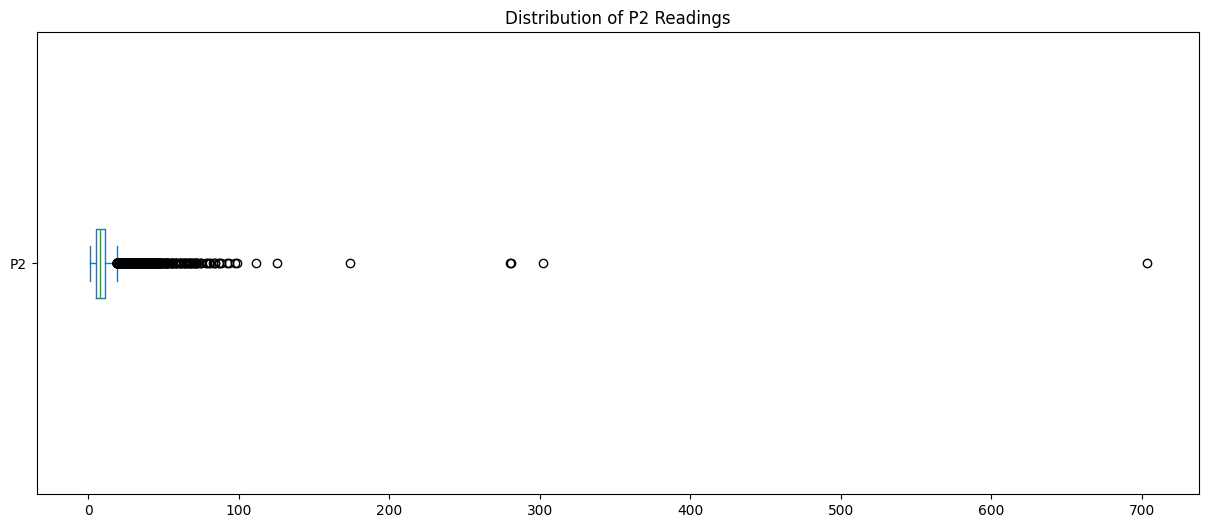

In [ ]:
# Visualize the data
fig, ax = plt.subplots(figsize=(15, 6))
df["P2"].plot(kind="box", vert=False, title="Distribution of P2 Readings",ax=ax)

In [ ]:
df = wrangle(nairobi)
print(df.shape)
df.head(10)

(32907, 1)


,P2
timestamp,
2018-09-01 03:00:02.472000+03:00,34.43
2018-09-01 03:05:03.941000+03:00,30.53
2018-09-01 03:10:04.374000+03:00,22.80
2018-09-01 03:15:04.245000+03:00,13.30
2018-09-01 03:20:04.869000+03:00,16.57
2018-09-01 03:25:04.659000+03:00,14.07
2018-09-01 03:30:05.406000+03:00,16.33
2018-09-01 03:35:04.259000+03:00,16.50
2018-09-01 03:40:04.219000+03:00,12.43


In [ ]:
# Wrangle Function
def wrangle(collection):
    results = collection.find(
        {"metadata.site": 29, "metadata.measurement": "P2"},
        projection={"P2": 1, "timestamp": 1, "_id": 0},
    )

    df = pd.DataFrame(results)

    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # Set as index
    df = df.set_index("timestamp")

    # If timezone-naive → localize
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    
    # localised timezone
    df.index = df.index.tz_convert("UTC").tz_convert("Africa/Nairobi")
    
    #Remove Outliers
    df = df[df["P2"] < 500]

    return df

In [ ]:
df = wrangle(nairobi)
print(df.shape)
df.head(10)

(32906, 1)


,P2
timestamp,
2018-09-01 03:00:02.472000+03:00,34.43
2018-09-01 03:05:03.941000+03:00,30.53
2018-09-01 03:10:04.374000+03:00,22.80
2018-09-01 03:15:04.245000+03:00,13.30
2018-09-01 03:20:04.869000+03:00,16.57
2018-09-01 03:25:04.659000+03:00,14.07
2018-09-01 03:30:05.406000+03:00,16.33
2018-09-01 03:35:04.259000+03:00,16.50
2018-09-01 03:40:04.219000+03:00,12.43


<Axes: xlabel='timestamp'>

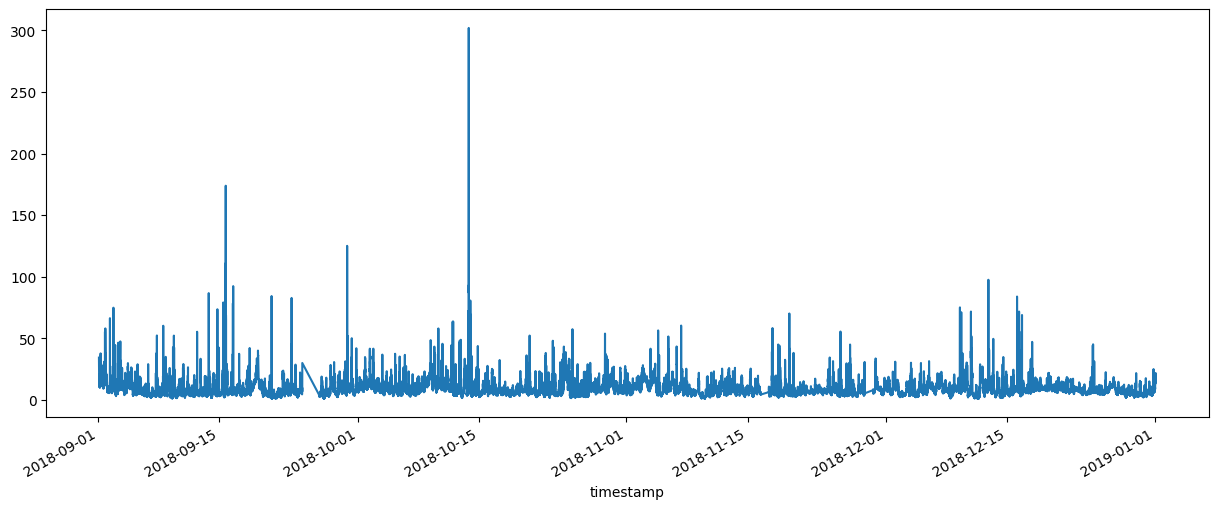

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
df["P2"].plot(ax=ax)

<Axes: title={'center': 'PM 2.5 Time Series'}, xlabel='Time', ylabel='PM2.5'>

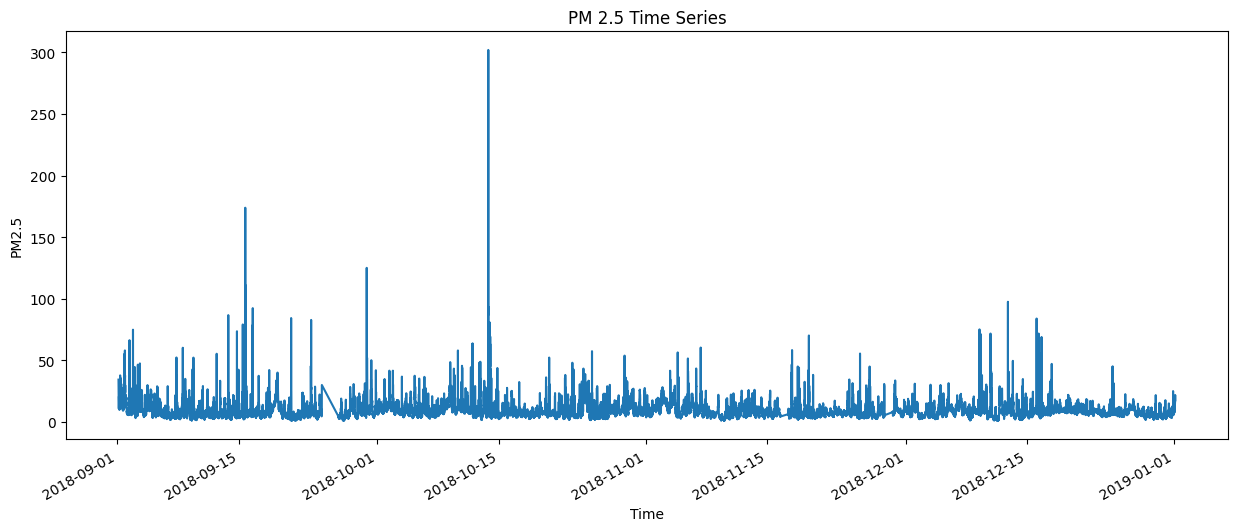

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
df["P2"].plot(xlabel="Time", ylabel="PM2.5", title="PM 2.5 Time Series", ax=ax)

In [ ]:
# Wrangle Function
def wrangle(collection):
    results = collection.find(
        {"metadata.site": 29, "metadata.measurement": "P2"},
        projection={"P2": 1, "timestamp": 1, "_id": 0},
    )

    df = pd.DataFrame(results)

    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # Set as index
    df = df.set_index("timestamp")

    # If timezone-naive → localize
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    
    # localised timezone
    df.index = df.index.tz_convert("UTC").tz_convert("Africa/Nairobi")
    
    #Remove Outliers
    df = df[df["P2"] < 500]
    

    return df
#...................................................
df = wrangle(nairobi)
print(df.shape)
df.head(10)

(32906, 1)


,P2
timestamp,
2018-09-01 03:00:02.472000+03:00,34.43
2018-09-01 03:05:03.941000+03:00,30.53
2018-09-01 03:10:04.374000+03:00,22.80
2018-09-01 03:15:04.245000+03:00,13.30
2018-09-01 03:20:04.869000+03:00,16.57
2018-09-01 03:25:04.659000+03:00,14.07
2018-09-01 03:30:05.406000+03:00,16.33
2018-09-01 03:35:04.259000+03:00,16.50
2018-09-01 03:40:04.219000+03:00,12.43


In [ ]:
# Resample data to hourly
df["P2"].resample("H")

<ipython-input-81-9b404bb156bf>:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["P2"].resample("H")


In [ ]:
# Resample data to hourly
df["P2"].resample("H").mean().head()

<ipython-input-82-2d6c5e825a0b>:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["P2"].resample("H").mean().head()


timestamp
2018-09-01 03:00:00+03:00    17.541667
2018-09-01 04:00:00+03:00    15.800000
2018-09-01 05:00:00+03:00    11.420000
2018-09-01 06:00:00+03:00    11.614167
2018-09-01 07:00:00+03:00    17.665000
Freq: h, Name: P2, dtype: float64

In [ ]:
df["P2"].resample("H").mean().isnull()

<ipython-input-83-c9eeb8fa497f>:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["P2"].resample("H").mean().isnull()


timestamp
2018-09-01 03:00:00+03:00    False
2018-09-01 04:00:00+03:00    False
2018-09-01 05:00:00+03:00    False
2018-09-01 06:00:00+03:00    False
2018-09-01 07:00:00+03:00    False
                             ...  
2018-12-31 22:00:00+03:00    False
2018-12-31 23:00:00+03:00    False
2019-01-01 00:00:00+03:00    False
2019-01-01 01:00:00+03:00    False
2019-01-01 02:00:00+03:00    False
Freq: h, Name: P2, Length: 2928, dtype: bool

In [ ]:
df["P2"].resample("H").mean().isnull().sum()

<ipython-input-84-e96acc169225>:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["P2"].resample("H").mean().isnull().sum()


np.int64(102)

In [ ]:
df["P2"].resample("H").mean().fillna(method="ffill").head() #.isnull().sum()

<ipython-input-85-1c51280f4eda>:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["P2"].resample("H").mean().fillna(method="ffill").head() #.isnull().sum()
<ipython-input-85-1c51280f4eda>:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["P2"].resample("H").mean().fillna(method="ffill").head() #.isnull().sum()


timestamp
2018-09-01 03:00:00+03:00    17.541667
2018-09-01 04:00:00+03:00    15.800000
2018-09-01 05:00:00+03:00    11.420000
2018-09-01 06:00:00+03:00    11.614167
2018-09-01 07:00:00+03:00    17.665000
Freq: h, Name: P2, dtype: float64

In [ ]:
df["P2"].resample("H").mean().fillna(method="ffill").head().isnull().sum()

<ipython-input-86-05249f596918>:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["P2"].resample("H").mean().fillna(method="ffill").head().isnull().sum()
<ipython-input-86-05249f596918>:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["P2"].resample("H").mean().fillna(method="ffill").head().isnull().sum()


np.int64(0)

In [ ]:
df["P2"].resample("h").mean().ffill().to_frame().head() # updated syntax

,P2
timestamp,
2018-09-01 03:00:00+03:00,17.541667
2018-09-01 04:00:00+03:00,15.800000
2018-09-01 05:00:00+03:00,11.420000
2018-09-01 06:00:00+03:00,11.614167
2018-09-01 07:00:00+03:00,17.665000


In [ ]:
# Wrangle Function
def wrangle(collection):
    results = collection.find(
        {"metadata.site": 29, "metadata.measurement": "P2"},
        projection={"P2": 1, "timestamp": 1, "_id": 0},
    )

    df = pd.DataFrame(results)

    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # Set as index
    df = df.set_index("timestamp")

    # If timezone-naive → localize
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    
    # localised timezone
    df.index = df.index.tz_convert("UTC").tz_convert("Africa/Nairobi")
    
    #Remove Outliers
    df = df[df["P2"] < 500]
    
    # Resample to 1 hour window, fill missing values
    df = df["P2"].resample("h").mean().ffill().to_frame() # updated syntax

    

    return df
#...................................................
df = wrangle(nairobi)
print(df.shape)
df.head(10)

(2928, 1)


,P2
timestamp,
2018-09-01 03:00:00+03:00,17.541667
2018-09-01 04:00:00+03:00,15.800000
2018-09-01 05:00:00+03:00,11.420000
2018-09-01 06:00:00+03:00,11.614167
2018-09-01 07:00:00+03:00,17.665000
2018-09-01 08:00:00+03:00,21.016667
2018-09-01 09:00:00+03:00,22.589167
2018-09-01 10:00:00+03:00,18.605833
2018-09-01 11:00:00+03:00,14.022500


<Axes: title={'center': 'Distribution of P2 Readings'}>

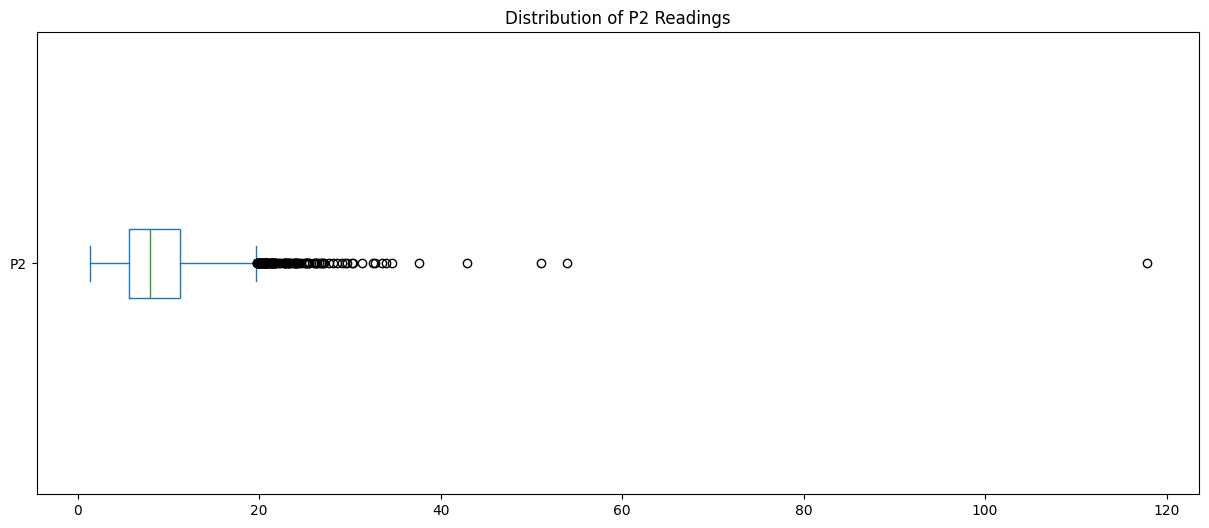

In [ ]:
# Visualize the data
fig, ax = plt.subplots(figsize=(15, 6))
df["P2"].plot(kind="box", vert=False, title="Distribution of P2 Readings",ax=ax)

<Axes: title={'center': 'PM 2.5 Time Series'}, xlabel='Time', ylabel='PM2.5'>

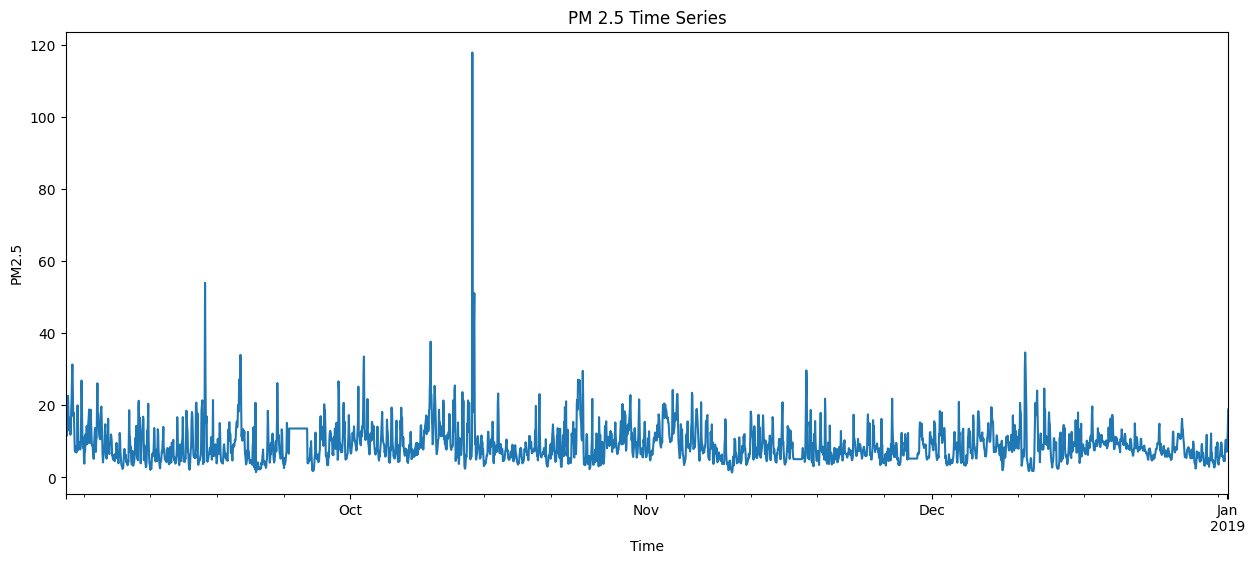

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
df["P2"].plot(xlabel="Time", ylabel="PM2.5", title="PM 2.5 Time Series", ax=ax)

In [ ]:
df["P2"].rolling(168).mean().head()

timestamp
2018-09-01 03:00:00+03:00   NaN
2018-09-01 04:00:00+03:00   NaN
2018-09-01 05:00:00+03:00   NaN
2018-09-01 06:00:00+03:00   NaN
2018-09-01 07:00:00+03:00   NaN
Freq: h, Name: P2, dtype: float64

In [ ]:
df["P2"].rolling(168).mean().tail()

timestamp
2018-12-31 22:00:00+03:00    6.932995
2018-12-31 23:00:00+03:00    6.935927
2019-01-01 00:00:00+03:00    6.938348
2019-01-01 01:00:00+03:00    6.973928
2019-01-01 02:00:00+03:00    7.043333
Freq: h, Name: P2, dtype: float64

In [ ]:
df["P2"].rolling(168).mean().isnull().sum()

np.int64(167)

<Axes: title={'center': 'weekly rolling avearage'}, xlabel='timestamp', ylabel='PM2.5'>

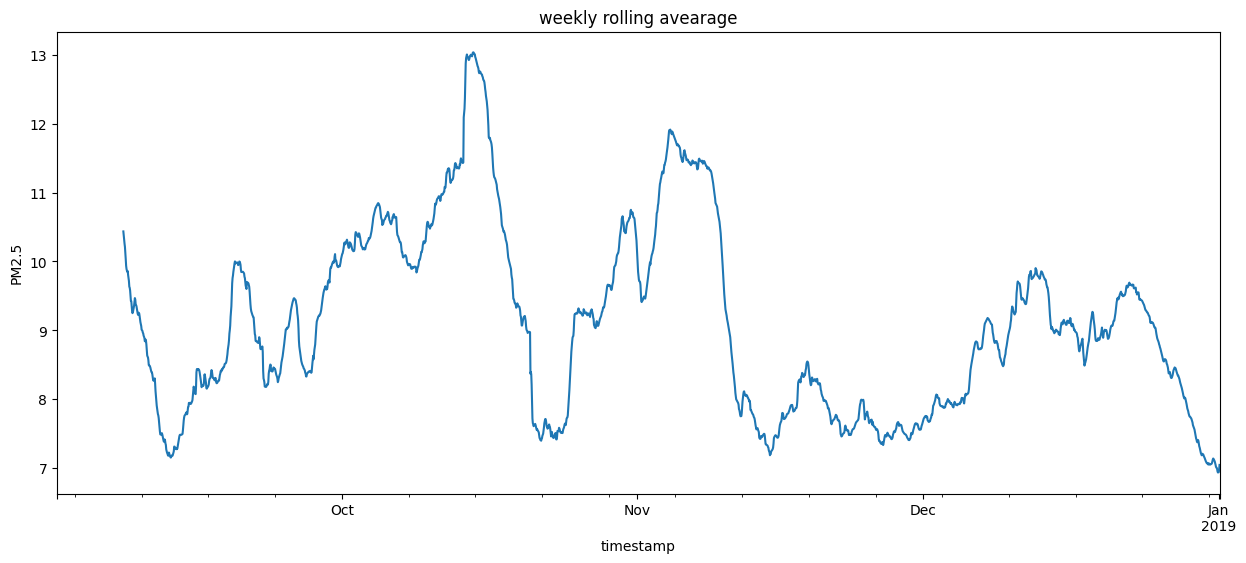

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
df["P2"].rolling(168).mean().plot(ax=ax, ylabel="PM2.5", title= "weekly rolling avearage")

In [ ]:
df["P2.Lag1"] = df["P2"].shift(1)
df.head()

,P2,P2.Lag1
timestamp,,
2018-09-01 03:00:00+03:00,17.541667,NaN
2018-09-01 04:00:00+03:00,15.800000,17.541667
2018-09-01 05:00:00+03:00,11.420000,15.800000
2018-09-01 06:00:00+03:00,11.614167,11.420000
2018-09-01 07:00:00+03:00,17.665000,11.614167


In [ ]:
# Create a time Lag
df["P2.Lag1"] = df["P2"].shift(1)
# drop missing values
df.dropna().head()

,P2,P2.Lag1
timestamp,,
2018-09-01 04:00:00+03:00,15.800000,17.541667
2018-09-01 05:00:00+03:00,11.420000,15.800000
2018-09-01 06:00:00+03:00,11.614167,11.420000
2018-09-01 07:00:00+03:00,17.665000,11.614167
2018-09-01 08:00:00+03:00,21.016667,17.665000


In [ ]:
# Wrangle Function
def wrangle(collection):
    results = collection.find(
        {"metadata.site": 29, "metadata.measurement": "P2"},
        projection={"P2": 1, "timestamp": 1, "_id": 0}
    )
    df = pd.DataFrame(results)
    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    # Set as index
    df = df.set_index("timestamp")
    # If timezone-naive → localize
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    
    # localised timezone
    df.index = df.index.tz_convert("UTC").tz_convert("Africa/Nairobi")
    
    #Remove Outliers
    df = df[df["P2"] < 500]
    
    # Resample to 1 hour window, fill missing values
    df = df["P2"].resample("h").mean().ffill().to_frame() # updated syntax

    # Create a time Lag feature
    df["P2.Lag1"] = df["P2"].shift(1)
    
    # drop missing values
    df.dropna(inplace=True)

    return df
#...................................................
df = wrangle(nairobi)
print(df.shape)
df.head(10)

(2927, 2)


,P2,P2.Lag1
timestamp,,
2018-09-01 04:00:00+03:00,15.800000,17.541667
2018-09-01 05:00:00+03:00,11.420000,15.800000
2018-09-01 06:00:00+03:00,11.614167,11.420000
2018-09-01 07:00:00+03:00,17.665000,11.614167
2018-09-01 08:00:00+03:00,21.016667,17.665000
2018-09-01 09:00:00+03:00,22.589167,21.016667
2018-09-01 10:00:00+03:00,18.605833,22.589167
2018-09-01 11:00:00+03:00,14.022500,18.605833
2018-09-01 12:00:00+03:00,13.150000,14.022500


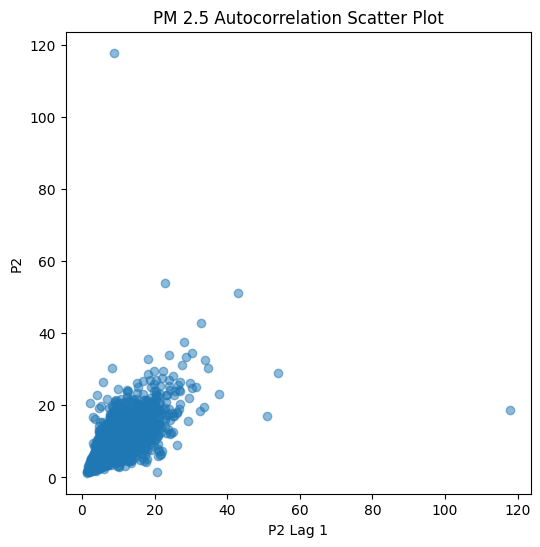

In [ ]:
# scatter plot that shows PM 2.5 mean reading 
# for each hour as a function of the mean reading from the previous hour.
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x=df["P2.Lag1"], y=df["P2"], alpha=0.5)
plt.xlabel("P2 Lag 1")
plt.ylabel("P2")
plt.title("PM 2.5 Autocorrelation Scatter Plot")
plt.show()

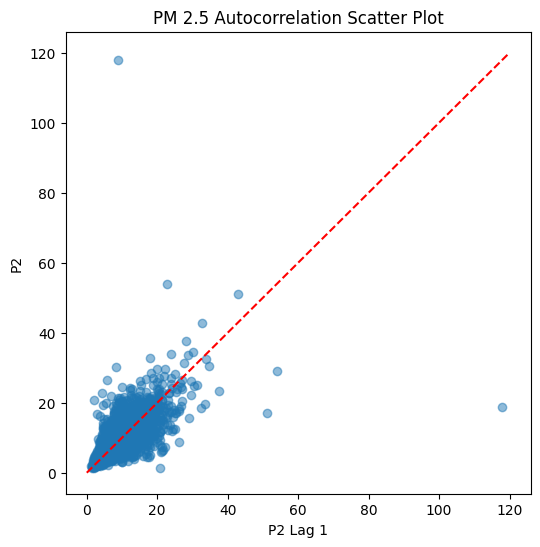

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x=df["P2.Lag1"], y=df["P2"], alpha=0.5)
ax.plot([0,120], [0,120], color="red", linestyle="--")
plt.xlabel("P2 Lag 1")
plt.ylabel("P2")
plt.title("PM 2.5 Autocorrelation Scatter Plot")
plt.show()

In [ ]:
# Split data
target = "P2"
y = df[target]
X = df.drop(columns=[target])

In [ ]:
y.head()

timestamp
2018-09-01 04:00:00+03:00    15.800000
2018-09-01 05:00:00+03:00    11.420000
2018-09-01 06:00:00+03:00    11.614167
2018-09-01 07:00:00+03:00    17.665000
2018-09-01 08:00:00+03:00    21.016667
Freq: h, Name: P2, dtype: float64

In [ ]:
X.head()

,P2.Lag1
timestamp,
2018-09-01 04:00:00+03:00,17.541667
2018-09-01 05:00:00+03:00,15.800000
2018-09-01 06:00:00+03:00,11.420000
2018-09-01 07:00:00+03:00,11.614167
2018-09-01 08:00:00+03:00,17.665000


In [ ]:
#get the 80th percentile index
cutoff = int(0.8 * len(df))

In [ ]:
# training data 
X_train, y_train = X.iloc[:cutoff], y.iloc[:cutoff]
# testing data
X_test, y_test = X.iloc[cutoff:], y.iloc[cutoff:]

In [ ]:
len(X_train), len(X_test)

(2341, 586)

In [ ]:
# check lengths fo X
len(X_train), len(X_test)
len(X_train) + len(X_test) == len(X)

True

In [ ]:
# check lengths of y
len(y_train), len(y_test)
len(y_train) + len(y_test) == len(y)

True

In [ ]:
# Baseline Model
# Always predict the mean of the training data
y_pred_baseline = [y_train.mean()] * len(y_train)
# Compute MAE
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)
# Print results
print("Mean P2 Reading:", round(y_train.mean(), 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean P2 Reading: 9.27
Baseline MAE: 3.89


In [ ]:
# Linear Regression Model
# Instantiate the model
model = LinearRegression()

In [ ]:
# Fit the model
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Make predictions
y_pred_train = model.predict(X_train)
y_pred_train[:5]

array([14.54530081, 13.43430172, 10.64032504, 10.76418283, 14.62397443])

In [ ]:
# Evaluate the model on training data
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, model.predict(X_test))
# Print results
print("Training MAE:", round(train_mae, 2))
print("Testing MAE:", round(test_mae, 2))

Training MAE: 2.46
Testing MAE: 1.8


In [ ]:
# Communicate results
intercept = model.intercept_.round(2)
coefficient = model.coef_.round(2)
print(f"P2 = {intercept} + ({coefficient} * P2.L1)")

P2 = 3.36 + ([0.64] * P2.L1)


In [ ]:
df_pred_test = pd.DataFrame(
    {
        "y_test": y_test,
        "y_pred": model.predict(X_test)
    }
)
df_pred_test.head()

,y_test,y_pred
timestamp,,
2018-12-07 17:00:00+03:00,7.070000,8.478927
2018-12-07 18:00:00+03:00,8.968333,7.865485
2018-12-07 19:00:00+03:00,11.630833,9.076421
2018-12-07 20:00:00+03:00,11.525833,10.774814
2018-12-07 21:00:00+03:00,9.533333,10.707836


In [ ]:
# Visualize predictions vs actuals
fig = px.line(df_pred_test, labels={"value": "P2"})

# Rename legend entries
legend_names = {
    "y_test": "Actual P2",
    "y_pred": "Predicted P2"
}
fig.for_each_trace(
    lambda trace: trace.update(name=legend_names.get(trace.name, trace.name))
)

# Move legend above the chart
fig.update_layout(
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.05,
        xanchor="center",
        x=0.5
    )
)

fig.show()

In [ ]:
# Visualize predictions vs actuals
fig = px.line(df_pred_test, labels={"value": "P2"})

legend_names = {
    "y_test": "Actual P2",
    "y_pred": "Predicted P2"
}
fig.for_each_trace(
    lambda trace: trace.update(name=legend_names.get(trace.name, trace.name))
)

# Move legend above
fig.update_layout(
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.05,
        xanchor="center",
        x=0.5
    ),
    width=1500,   # <--- Make wider
    height=600
)

fig.show()